In [7]:
# Importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [8]:
# Loading the Framingham dataset

df = pd.read_csv("framingham.csv")

# Display the first five rows
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [9]:
# Checking the number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4238
Number of columns: 16


In [10]:
# Displaying all column names

print("Column Names:")
print(df.columns.tolist())

Column Names:
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


In [11]:
# Checking the data types of each column

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [12]:
# Generating basic statistical information

df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [13]:
# Checking for missing values in each column

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


In [14]:
# Calculating the percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
print(missing_percentage)

Missing Value Percentage:
male               0.000000
age                0.000000
education          2.477584
currentSmoker      0.000000
cigsPerDay         0.684285
BPMeds             1.250590
prevalentStroke    0.000000
prevalentHyp       0.000000
diabetes           0.000000
totChol            1.179802
sysBP              0.000000
diaBP              0.000000
BMI                0.448325
heartRate          0.023596
glucose            9.155262
TenYearCHD         0.000000
dtype: float64


In [15]:
# Filling missing values in numerical columns using the median

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Checking again for missing values
print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [16]:
# Checking the target variable distribution

print(df["TenYearCHD"].value_counts())

TenYearCHD
0    3594
1     644
Name: count, dtype: int64


In [17]:
# Displaying the percentage distribution of the target variable

print(df["TenYearCHD"].value_counts(normalize=True) * 100)

TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64


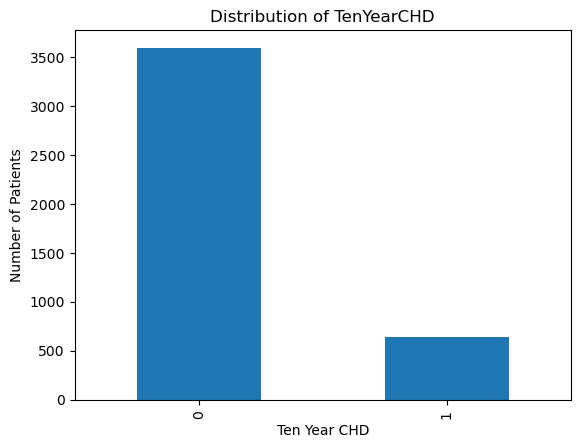

In [18]:
# Visualizing the distribution of the target variable

df["TenYearCHD"].value_counts().plot(kind="bar")

plt.title("Distribution of TenYearCHD")
plt.xlabel("Ten Year CHD")
plt.ylabel("Number of Patients")
plt.show()

In [19]:
# Separating independent variables (features) and dependent variable (target)

X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("TenYearCHD")

Features:
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

Target:
TenYearCHD


In [20]:
# Checking categorical/object columns

categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
[]


In [21]:
# Splitting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3390, 15)
Testing data: (848, 15)


In [22]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [23]:
# Importing SMOTE for handling class imbalance

from imblearn.over_sampling import SMOTE

In [24]:
# Applying SMOTE only to the training data

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
TenYearCHD
0    2875
1     515
Name: count, dtype: int64

After SMOTE:
TenYearCHD
0    2875
1    2875
Name: count, dtype: int64


In [25]:
# Creating the StandardScaler

scaler = StandardScaler()

# Fitting the scaler on the balanced training data
# and transforming the training data

X_train_scaled = scaler.fit_transform(X_train_balanced)

# Transforming the test data using the same scaler

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [26]:
# Creating the Logistic Regression model

logistic_model = LogisticRegression(random_state=42)

# Training the model

logistic_model.fit(X_train_scaled, y_train_balanced)

# Making predictions

y_pred_logistic = logistic_model.predict(X_test_scaled)

In [27]:
# Evaluating Logistic Regression

print("Logistic Regression")
print("-------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression
-------------------------
Accuracy : 0.6462264150943396
Precision: 0.21782178217821782
Recall   : 0.5116279069767442
F1 Score : 0.3055555555555556

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.67      0.76       719
           1       0.22      0.51      0.31       129

    accuracy                           0.65       848
   macro avg       0.55      0.59      0.53       848
weighted avg       0.78      0.65      0.69       848



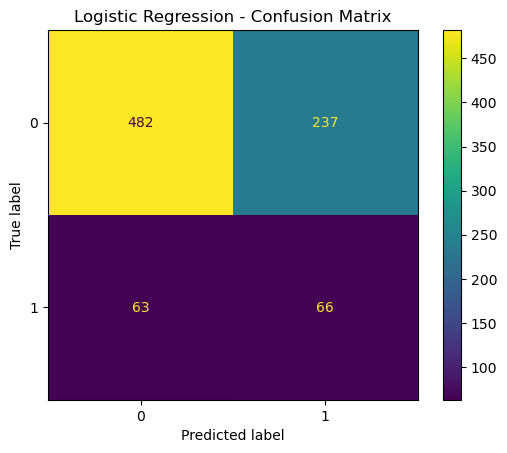

In [28]:
# Creating the confusion matrix for Logistic Regression

cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [29]:
# Creating the Decision Tree model

decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Training the model

decision_tree.fit(X_train_balanced, y_train_balanced)

# Making predictions

y_pred_tree = decision_tree.predict(X_test)

In [30]:
# Evaluating Decision Tree

print("Decision Tree")
print("-------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1 Score :", f1_score(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree
-------------------------
Accuracy : 0.714622641509434
Precision: 0.15757575757575756
Recall   : 0.20155038759689922
F1 Score : 0.17687074829931973

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       719
           1       0.16      0.20      0.18       129

    accuracy                           0.71       848
   macro avg       0.50      0.50      0.50       848
weighted avg       0.74      0.71      0.73       848



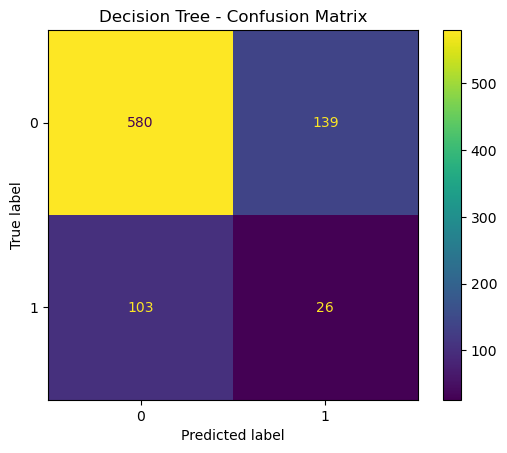

In [31]:
# Confusion Matrix for Decision Tree

cm = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [32]:
# Creating the Random Forest model

random_forest = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

# Training the model

random_forest.fit(X_train_balanced, y_train_balanced)

# Making predictions

y_pred_rf = random_forest.predict(X_test)

In [33]:
# Evaluating Random Forest

print("Random Forest")
print("-------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest
-------------------------
Accuracy : 0.8054245283018868
Precision: 0.1896551724137931
Recall   : 0.08527131782945736
F1 Score : 0.11764705882352941

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       719
           1       0.19      0.09      0.12       129

    accuracy                           0.81       848
   macro avg       0.52      0.51      0.50       848
weighted avg       0.75      0.81      0.77       848



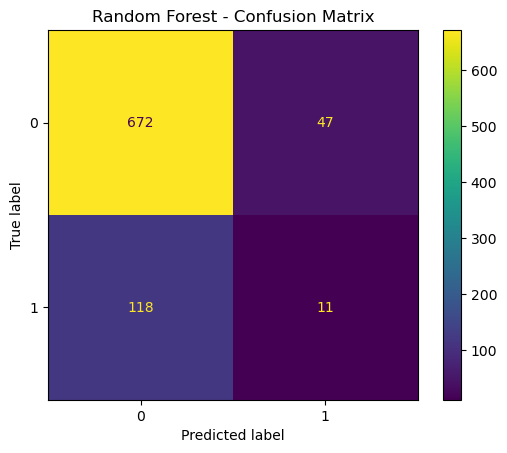

In [34]:
# Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [35]:
# Creating the K-Nearest Neighbors model

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

# Training the model

knn_model.fit(X_train_scaled, y_train_balanced)

# Making predictions

y_pred_knn = knn_model.predict(X_test_scaled)

In [36]:
# Evaluating KNN

print("K-Nearest Neighbors")
print("-------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

K-Nearest Neighbors
-------------------------
Accuracy : 0.6238207547169812
Precision: 0.17905405405405406
Recall   : 0.4108527131782946
F1 Score : 0.24941176470588236

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.66      0.75       719
           1       0.18      0.41      0.25       129

    accuracy                           0.62       848
   macro avg       0.52      0.54      0.50       848
weighted avg       0.76      0.62      0.67       848



In [37]:
# Comparing the performance of all classification models

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.646226,0.217822,0.511628,0.305556
1,Decision Tree,0.714623,0.157576,0.201550,0.176871
2,Random Forest,0.805425,0.189655,0.085271,0.117647
3,KNN,0.623821,0.179054,0.410853,0.249412


In [38]:
# Selecting the best model based on F1 Score

best_model_name = model_results.loc[
    model_results["F1 Score"].idxmax(), "Model"
]

print("Best Performing Model:", best_model_name)

Best Performing Model: Logistic Regression


In [39]:
# Importing GridSearchCV for hyperparameter tuning

from sklearn.model_selection import GridSearchCV

In [40]:
# Defining hyperparameters for Random Forest

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [41]:
# Performing hyperparameter tuning

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_balanced, y_train_balanced)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [42]:
# Displaying the best parameters

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation F1 Score:
0.9002054914377456


In [44]:
# Displaying the best parameters

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation F1 Score:
0.9002054914377456


In [45]:
# Getting the best tuned model

best_rf_model = grid_search.best_estimator_

# Making predictions using the tuned model

y_pred_tuned = best_rf_model.predict(X_test)

In [46]:
# Evaluating the tuned Random Forest model

print("Tuned Random Forest")
print("-------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Random Forest
-------------------------
Accuracy : 0.8089622641509434
Precision: 0.18867924528301888
Recall   : 0.07751937984496124
F1 Score : 0.10989010989010989

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       719
           1       0.19      0.08      0.11       129

    accuracy                           0.81       848
   macro avg       0.52      0.51      0.50       848
weighted avg       0.75      0.81      0.77       848



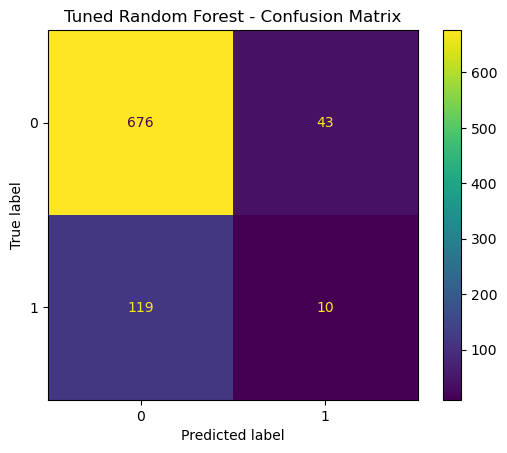

In [47]:
# Confusion Matrix for Tuned Random Forest

cm = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [48]:
# Comparing Random Forest before and after hyperparameter tuning

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    
    "Before Tuning": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ],
    
    "After Tuning": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned)
    ]
})

comparison

,Metric,Before Tuning,After Tuning
0,Accuracy,0.805425,0.808962
1,Precision,0.189655,0.188679
2,Recall,0.085271,0.077519
3,F1 Score,0.117647,0.109890
